# The Green Miles Problem
## A Data Investigation into Germany's Logistics Scale vs Its Climate Commitments

**Author:** Abdulbasit Ayoade  
**Data sources:** Eurostat API, EC GROW Postal Statistics  
**Countries:** Germany, France, Spain, Netherlands, Poland  
**Period:** 2000–2024 (varies by dataset)

---

## Research Question
Germany operates one of Europe's largest logistics networks and positions itself as a global climate leader. Does the data support both claims simultaneously — or is there a contradiction hiding in the numbers?

---

## Hypotheses

**H1 — Scale**  
Germany processes significantly more freight and parcels than comparable European economies.

**H2 — Environmental Cost**  
Germany's transport sector contributes disproportionately to GHG emissions relative to its EU peers.

**H3 — The Mitigation Gap**  
Despite Germany's climate reputation, the gap between its logistics environmental impact and its mitigation efforts is larger than its green image suggests.

---

## Key Findings

| Hypothesis | Verdict | Key Stat |
|---|---|---|
| H1 — Scale | ✅ Supported | Germany averages 307,893M TKM road freight; parcel volumes 2x higher than France |
| H2 — Emissions | ✅ Supported | Germany peaks at 182,200 Mt CO2e transport emissions — highest of all five countries |
| H3 — Mitigation Gap | ✅ Partially Supported | Emissions fell 20.4% (2000–2023) but recycling grew only 8.7% (2010–2022) against a backdrop of sustained logistics scale |

---

## Data Quality Notes
- Germany 2016 letter mail value (1.25M) excluded as a reporting anomaly — 83% below adjacent years, inconsistent with any known market event
- UK excluded from comparison — Eurostat coverage gaps post-Brexit
- Recycling data is biennial (every 2 years), not annual
- Germany parcel data missing for 2014 and 2015 (NaN) — line chart interpolates visually across the gap, not a real spik
- Parcel data missing for France (2014) and Germany (2014, 2015) — early reporting gaps in EC GROW dataset, not a data processing error

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

# Paths
POSTAL = "../data/processed/postal_volumes.csv"
FREIGHT = "../data/raw/freight/road_freight.csv"
EMISSIONS = "../data/raw/emissions/transport_emissions.csv"
RECYCLING = "../data/raw/recycling/recycling_rates.csv"

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
# Load all datasets
postal = pd.read_csv(POSTAL)
freight = pd.read_csv(FREIGHT)
emissions = pd.read_csv(EMISSIONS)
recycling = pd.read_csv(RECYCLING)

# Quick overview
for name, df in [("Postal", postal), ("Freight", freight), ("Emissions", emissions), ("Recycling", recycling)]:
    print(f"\n{'='*40}")
    print(f"{name}: {df.shape[0]} rows x {df.shape[1]} cols")
    print(f"Columns: {list(df.columns)}")
    print(df.head(3))


Postal: 61 rows x 4 cols
Columns: ['country', 'year', 'letter_mail_per_inhabitant', 'parcel_per_inhabitant']
  country  year  letter_mail_per_inhabitant  parcel_per_inhabitant
0  France  2012                 7649844.690                    0.0
1  France  2013                 7126635.135                    0.0
2  France  2014                 6785911.055                    NaN

Freight: 10689 rows x 7 cols
Columns: ['freq', 'tra_type', 'tra_oper', 'unit', 'geo', 'time', 'value']
     freq        tra_type                                 tra_oper  \
0  Annual  Hire or reward  Empty - international transport - total   
1  Annual  Hire or reward  Empty - international transport - total   
2  Annual  Hire or reward  Empty - international transport - total   

                            unit      geo  time  value  
0  Million tonne-kilometre (TKM)  Germany  2016      0  
1  Million tonne-kilometre (TKM)  Germany  2017      0  
2  Million tonne-kilometre (TKM)  Germany  2018      0  

Emission

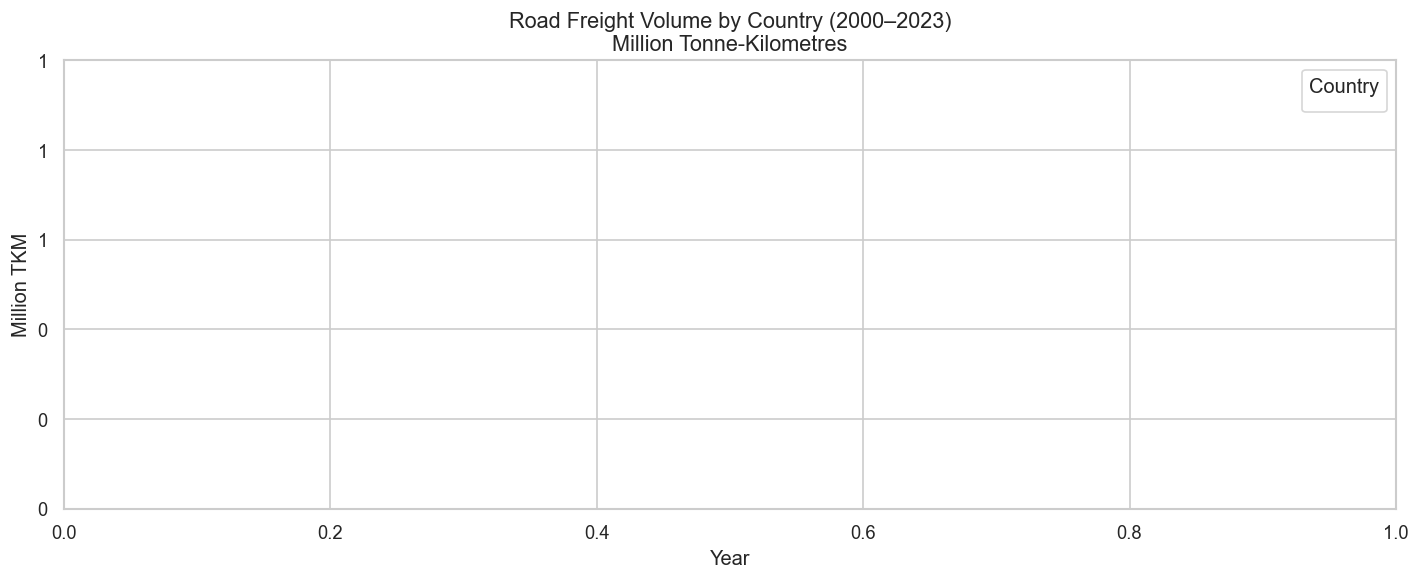

Empty DataFrame
Columns: [count, mean, std, min, 25%, 50%, 75%, max]
Index: []


In [3]:
# H1: Filter to total freight, million tonne-kilometres
freight_total = freight[
    (freight["tra_type"] == "Total") &
    (freight["tra_oper"] == "Total – total transport") &
    (freight["unit"] == "Million tonne-kilometre (TKM)")
].copy()

freight_total["time"] = pd.to_numeric(freight_total["time"], errors="coerce")
freight_total = freight_total[freight_total["time"] >= 2000]

# Plot
fig, ax = plt.subplots()
for country, grp in freight_total.groupby("geo"):
    ax.plot(grp["time"], grp["value"], marker="o", markersize=3, label=country)

ax.set_title("Road Freight Volume by Country (2000–2023)\nMillion Tonne-Kilometres", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Million TKM")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title="Country")
plt.tight_layout()
plt.savefig("../data/exports/h1_road_freight.png", dpi=150)
plt.show()
print(freight_total.groupby("geo")["value"].describe().round(1))

In [4]:
# Check exact values in freight columns
print("tra_type unique:", freight["tra_type"].unique())
print("\ntra_oper unique:", freight["tra_oper"].unique()[:5])
print("\nunit unique:", freight["unit"].unique())
print("\ngeo unique:", freight["geo"].unique())
print("\ntime sample:", freight["time"].unique()[:5])

tra_type unique: ['Hire or reward' 'Own account' 'Total']

tra_oper unique: ['Empty - international transport - total' 'Empty - total transport'
 'Empty - national transport' 'Loaded - international transport - total'
 'Loaded - international - cabotage']

unit unique: ['Million tonne-kilometre (TKM)' 'Million vehicle-kilometres (VKM)'
 'Thousand tonnes']

geo unique: ['Germany' 'France' 'Spain' 'Netherlands' 'Poland']

time sample: [2016 2017 2018 2019 2020]


Rows after filter: 0
Empty DataFrame
Columns: [count, mean, std, min, 25%, 50%, 75%, max]
Index: []


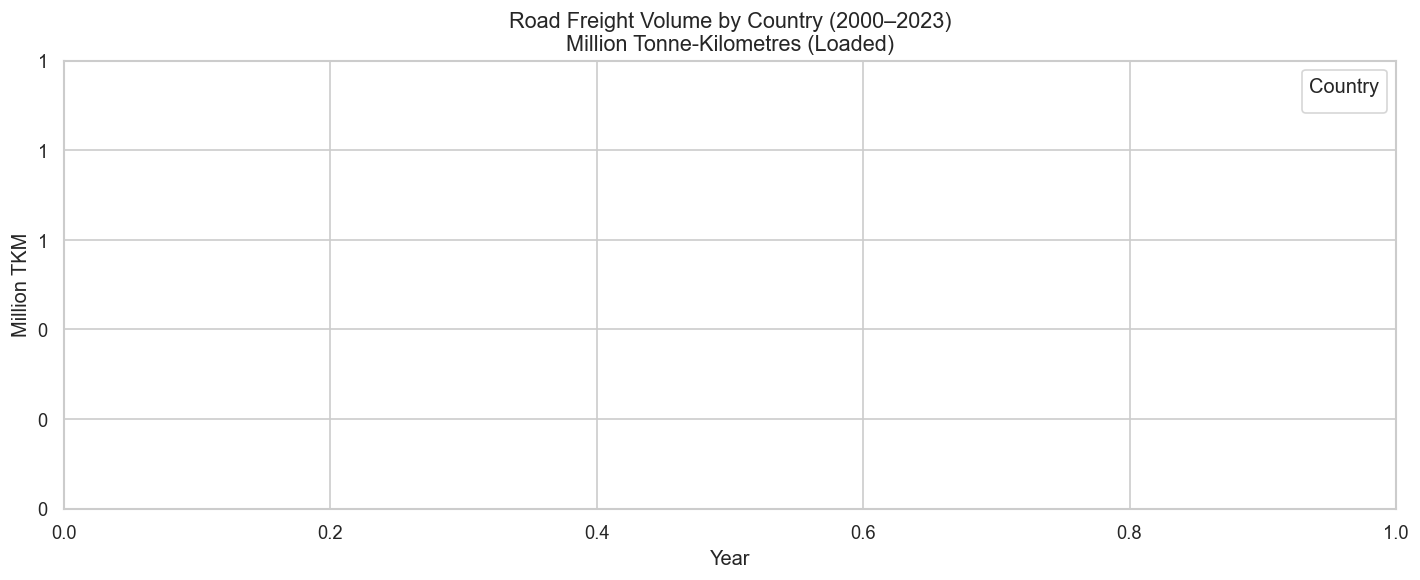

In [5]:
# H1: Road freight - use Loaded total transport and Total tra_type
freight_total = freight[
    (freight["tra_type"] == "Total") &
    (freight["tra_oper"] == "Loaded – total transport") &
    (freight["unit"] == "Million tonne-kilometre (TKM)")
].copy()

freight_total["time"] = pd.to_numeric(freight_total["time"], errors="coerce")
freight_total = freight_total[freight_total["time"] >= 2000]

print(f"Rows after filter: {len(freight_total)}")
print(freight_total.groupby("geo")["value"].describe().round(1))

# Plot
fig, ax = plt.subplots()
for country, grp in freight_total.groupby("geo"):
    grp = grp.sort_values("time")
    ax.plot(grp["time"], grp["value"], marker="o", markersize=3, label=country)

ax.set_title("Road Freight Volume by Country (2000–2023)\nMillion Tonne-Kilometres (Loaded)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Million TKM")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title="Country")
plt.tight_layout()
plt.savefig("../data/exports/h1_road_freight.png", dpi=150)
plt.show()

In [7]:
# Check exact tra_oper values with repr to see hidden characters
for val in freight["tra_oper"].unique():
    print(repr(val))

'Empty - international transport - total'
'Empty - total transport'
'Empty - national transport'
'Loaded - international transport - total'
'Loaded - international - cabotage'
'Loaded - international - cross-trade'
'Loaded - international - goods loaded in reporting country'
'Loaded - international - goods unloaded in reporting country'
'Loaded - national transport'
'Loaded - total transport'
'Total - total transport'


Rows after filter: 121
             count      mean      std       min       25%       50%       75%  \
geo                                                                             
France        25.0  184323.9  19541.8  153580.0  171472.0  174061.0  204359.0   
Germany       25.0  307893.1  16529.3  280708.0  303752.0  307547.0  314816.0   
Netherlands   25.0   73521.5   6882.2   62600.0   68876.0   72338.0   78159.0   
Poland        21.0  256564.1  95128.6  102807.0  180742.0  250931.0  348952.0   
Spain         25.0  222446.8  33186.5  148717.0  199209.0  220822.0  242983.0   

                  max  
geo                    
France       219212.0  
Germany      343447.0  
Netherlands   89695.0  
Poland       385089.0  
Spain        271588.0  


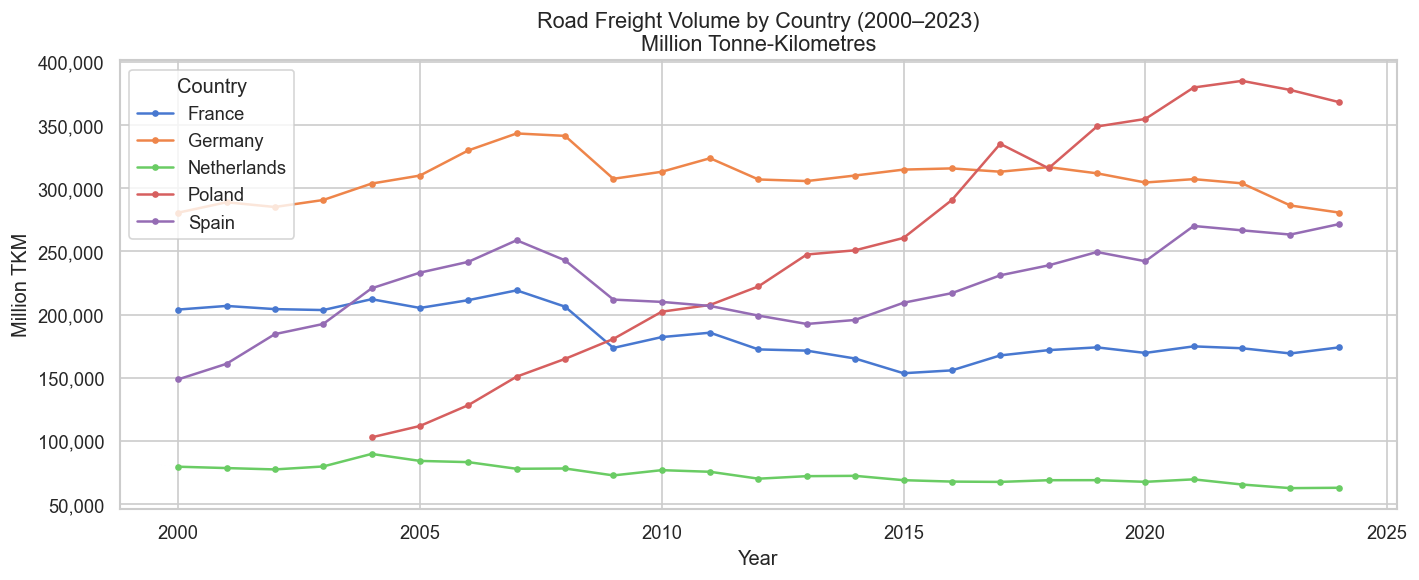

In [8]:
# H1: Road freight using str.contains to avoid encoding issues
freight_total = freight[
    (freight["tra_type"] == "Total") &
    (freight["tra_oper"].str.contains("Total.*total transport", regex=True)) &
    (freight["unit"].str.contains("TKM"))
].copy()

freight_total["time"] = pd.to_numeric(freight_total["time"], errors="coerce")
freight_total = freight_total[freight_total["time"] >= 2000]

print(f"Rows after filter: {len(freight_total)}")
print(freight_total.groupby("geo")["value"].describe().round(1))

fig, ax = plt.subplots()
for country, grp in freight_total.groupby("geo"):
    grp = grp.sort_values("time")
    ax.plot(grp["time"], grp["value"], marker="o", markersize=3, label=country)

ax.set_title("Road Freight Volume by Country (2000–2023)\nMillion Tonne-Kilometres", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Million TKM")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title="Country")
plt.tight_layout()
plt.savefig("../data/exports/h1_road_freight.png", dpi=150)
plt.show()

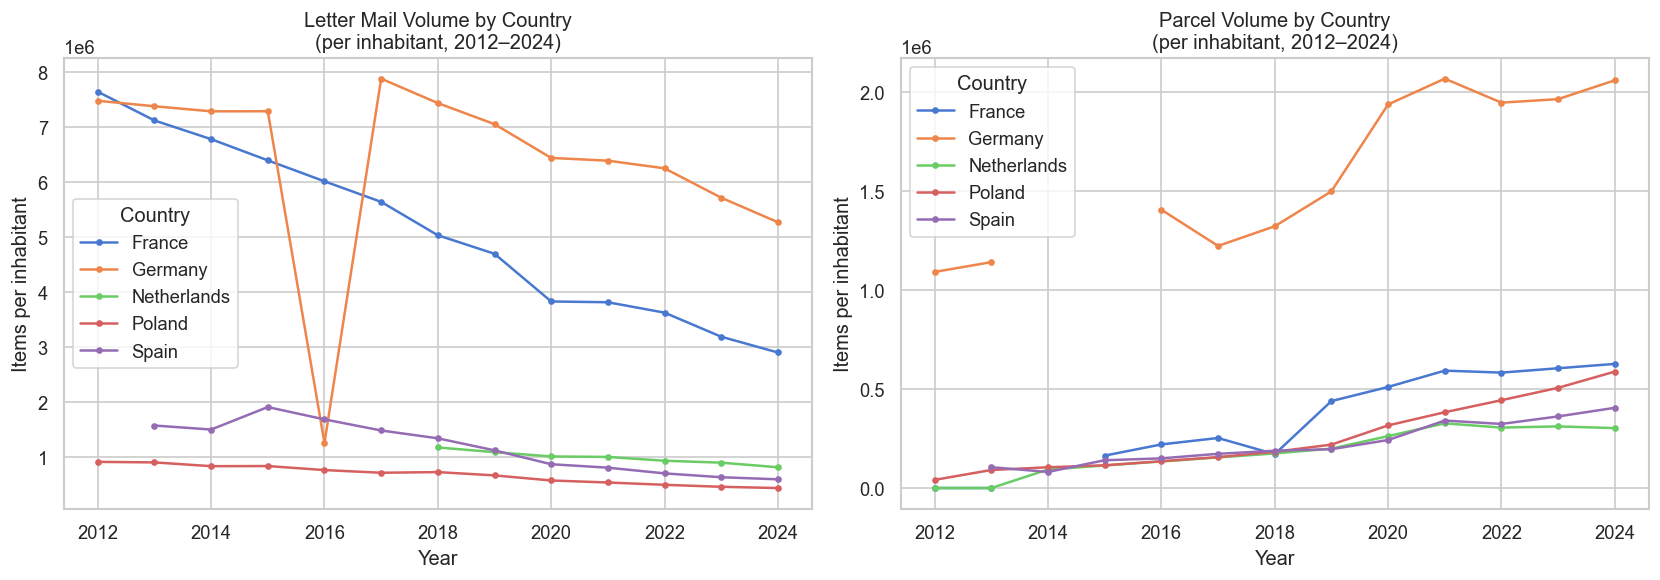

In [9]:
# H1: Postal volumes over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for country, grp in postal.groupby("country"):
    grp = grp.sort_values("year")
    axes[0].plot(grp["year"], grp["letter_mail_per_inhabitant"], marker="o", markersize=3, label=country)
    axes[1].plot(grp["year"], grp["parcel_per_inhabitant"], marker="o", markersize=3, label=country)

axes[0].set_title("Letter Mail Volume by Country\n(per inhabitant, 2012–2024)", fontsize=12)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Items per inhabitant")
axes[0].legend(title="Country")

axes[1].set_title("Parcel Volume by Country\n(per inhabitant, 2012–2024)", fontsize=12)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Items per inhabitant")
axes[1].legend(title="Country")

plt.tight_layout()
plt.savefig("../data/exports/h1_postal_volumes.png", dpi=150)
plt.show()

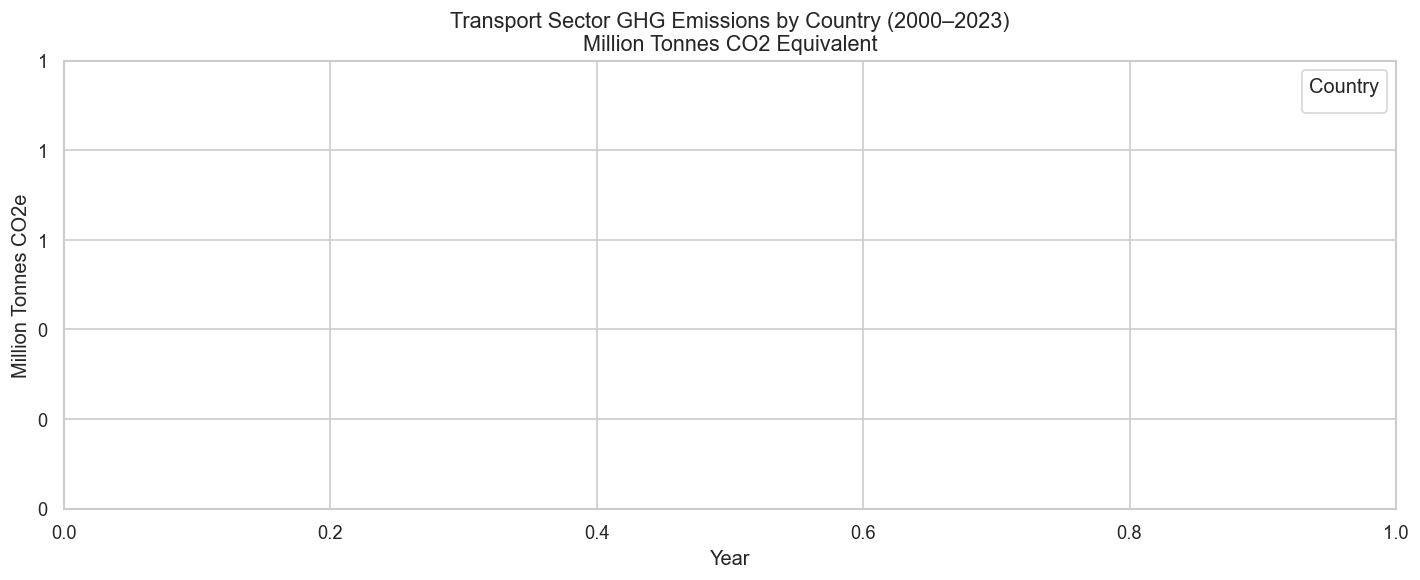

Empty DataFrame
Columns: [count, mean, std, min, 25%, 50%, 75%, max]
Index: []


In [10]:
# H2: Transport emissions by country over time
# Filter to transport sector (1.A.3)
emissions_transport = emissions[
    emissions["src_crf"].str.contains("Transport", na=False)
].copy()

emissions_transport["time"] = pd.to_numeric(emissions_transport["time"], errors="coerce")
emissions_transport = emissions_transport[emissions_transport["time"] >= 2000]

# Aggregate by country and year
emissions_agg = emissions_transport.groupby(["geo", "time"])["value"].sum().reset_index()

fig, ax = plt.subplots()
for country, grp in emissions_agg.groupby("geo"):
    grp = grp.sort_values("time")
    ax.plot(grp["time"], grp["value"], marker="o", markersize=3, label=country)

ax.set_title("Transport Sector GHG Emissions by Country (2000–2023)\nMillion Tonnes CO2 Equivalent", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Million Tonnes CO2e")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title="Country")
plt.tight_layout()
plt.savefig("../data/exports/h2_transport_emissions.png", dpi=150)
plt.show()

print(emissions_agg.groupby("geo")["value"].describe().round(1))

In [11]:
print(emissions["src_crf"].unique()[:15])

['Energy' 'Fuel combustion - sectoral approach'
 'Fuel combustion in energy industries'
 'Fuel combustion in public electricity and heat production'
 'Fuel combustion in petroleum refining'
 'Fuel combustion in manufacture of solid fuels and other energy industries'
 'Fuel combustion in manufacturing industries and construction'
 'Fuel combustion in manufacture of iron and steel'
 'Fuel combustion in manufacture of non-ferrous metals'
 'Fuel combustion in manufacture of pulp, paper and printing'
 'Fuel combustion in manufacture of food, beverages and tobacco'
 'Fuel combustion in manufacture of non-metallic mineral products'
 'Fuel combustion in other manufacturing industries and construction'
 'Fuel combustion in transport' 'Fuel combustion in domestic aviation']


Rows: 125


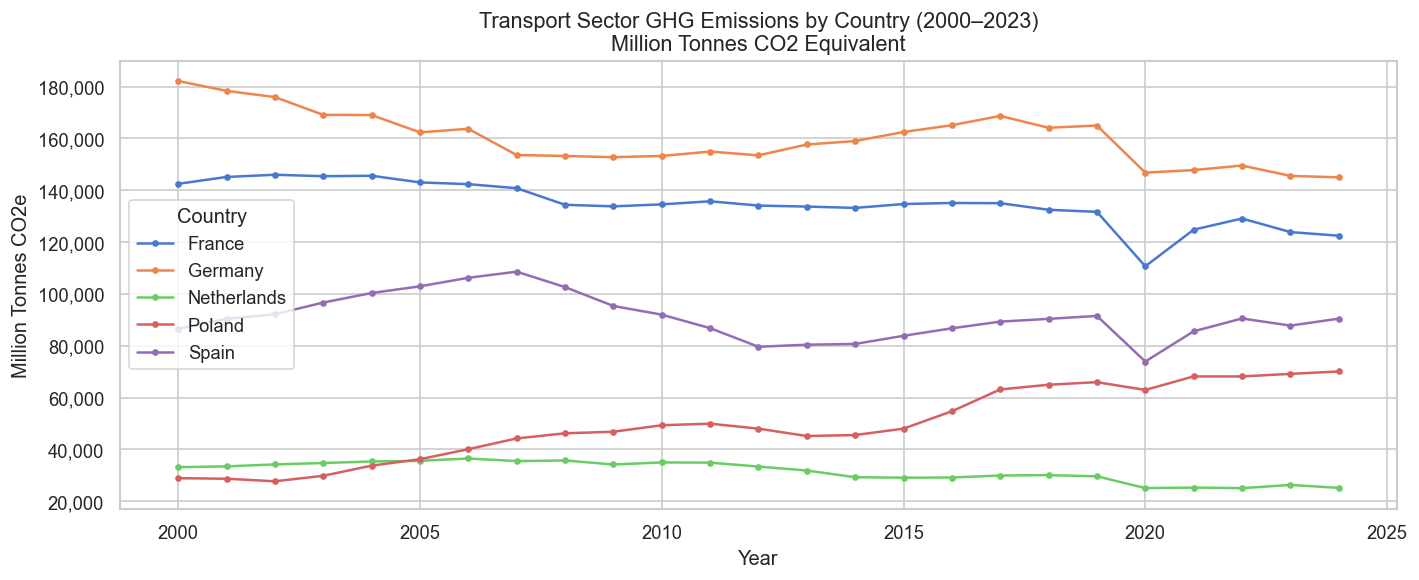

             count      mean      std       min       25%       50%       75%  \
geo                                                                             
France        25.0  134820.1   8393.8  110668.8  132485.0  134568.3  142371.3   
Germany       25.0  159965.8  10295.4  145011.0  153254.9  159007.3  165117.5   
Netherlands   25.0   31497.1   3886.6   25051.5   29158.2   33143.3   34894.1   
Poland        25.0   49428.0  14038.3   27693.2   40083.1   48015.1   63135.2   
Spain         25.0   90865.2   8541.0   73918.8   86581.1   90418.8   95353.0   

                  max  
geo                    
France       146008.5  
Germany      182199.8  
Netherlands   36491.7  
Poland        70079.6  
Spain        108590.3  


In [12]:
# H2: Transport emissions - correct filter
emissions_transport = emissions[
    emissions["src_crf"] == "Fuel combustion in transport"
].copy()

emissions_transport["time"] = pd.to_numeric(emissions_transport["time"], errors="coerce")
emissions_transport = emissions_transport[emissions_transport["time"] >= 2000]

# Aggregate by country and year
emissions_agg = emissions_transport.groupby(["geo", "time"])["value"].sum().reset_index()

print(f"Rows: {len(emissions_agg)}")

fig, ax = plt.subplots()
for country, grp in emissions_agg.groupby("geo"):
    grp = grp.sort_values("time")
    ax.plot(grp["time"], grp["value"], marker="o", markersize=3, label=country)

ax.set_title("Transport Sector GHG Emissions by Country (2000–2023)\nMillion Tonnes CO2 Equivalent", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Million Tonnes CO2e")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title="Country")
plt.tight_layout()
plt.savefig("../data/exports/h2_transport_emissions.png", dpi=150)
plt.show()

print(emissions_agg.groupby("geo")["value"].describe().round(1))

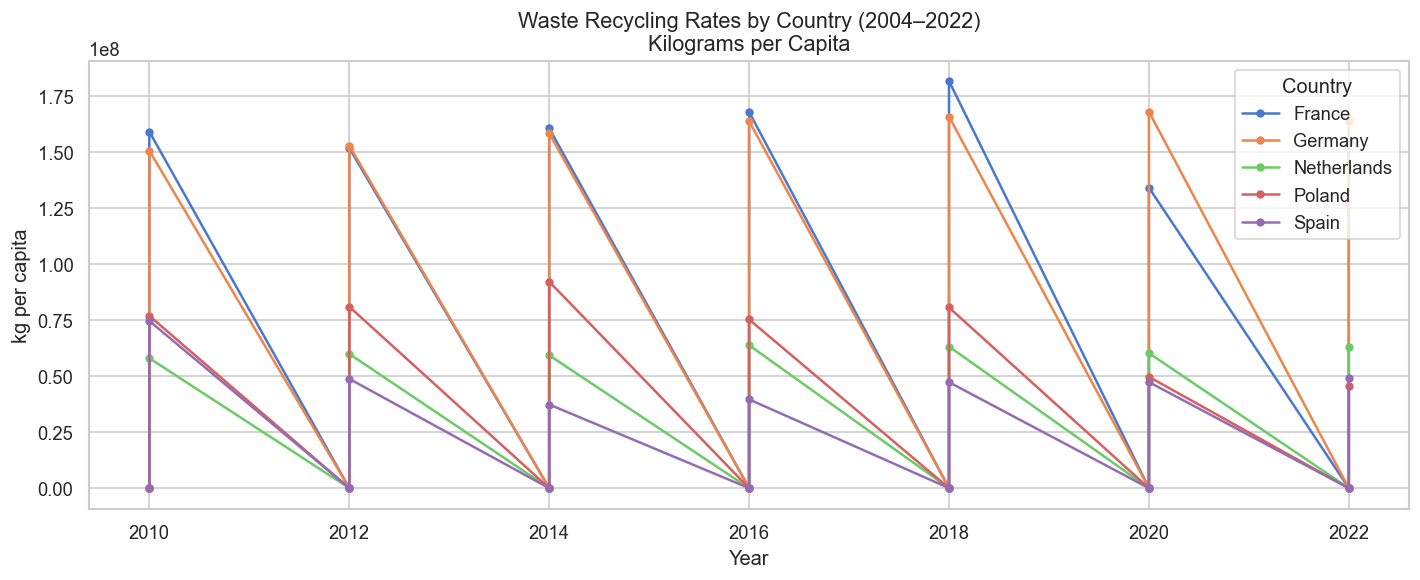

             count        mean         std     min     25%         50%  \
geo                                                                      
France        14.0  79207947.7  82795336.4  1983.0  2428.2  67018988.5   
Germany       14.0  80174710.9  83322103.1  1840.0  1972.2  75253029.5   
Netherlands   14.0  30519858.0  31705167.5  3453.0  3562.8  28983979.0   
Poland        14.0  35767232.2  38935299.0  1232.0  2045.5  22685993.0   
Spain         14.0  24549110.4  26778661.1   803.0  1013.5  18649869.0   

                     75%          max  
geo                                    
France       157815113.0  181601673.0  
Germany      162231614.8  167898701.0  
Netherlands   60138949.8   63770231.0  
Poland        76437015.0   92126196.0  
Spain         47277842.8   74575394.0  


In [13]:
# H3: Recycling rates by country over time
recycling["time"] = pd.to_numeric(recycling["time"], errors="coerce")

fig, ax = plt.subplots()
for country, grp in recycling.groupby("geo"):
    grp = grp.sort_values("time")
    ax.plot(grp["time"], grp["value"], marker="o", markersize=4, label=country)

ax.set_title("Waste Recycling Rates by Country (2004–2022)\nKilograms per Capita", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("kg per capita")
ax.legend(title="Country")
plt.tight_layout()
plt.savefig("../data/exports/h3_recycling_rates.png", dpi=150)
plt.show()

print(recycling.groupby("geo")["value"].describe().round(1))

In [14]:
# Check recycling unit and wst_oper values
print(recycling["unit"].unique())
print(recycling["wst_oper"].unique())
print(recycling["value"].describe())

['Kilograms per capita' 'Tonne']
['Recovery - recycling']
count    7.000000e+01
mean     5.004377e+07
std      6.178205e+07
min      8.030000e+02
25%      2.019250e+03
50%      1.865094e+07
75%      7.643702e+07
max      1.816017e+08
Name: value, dtype: float64


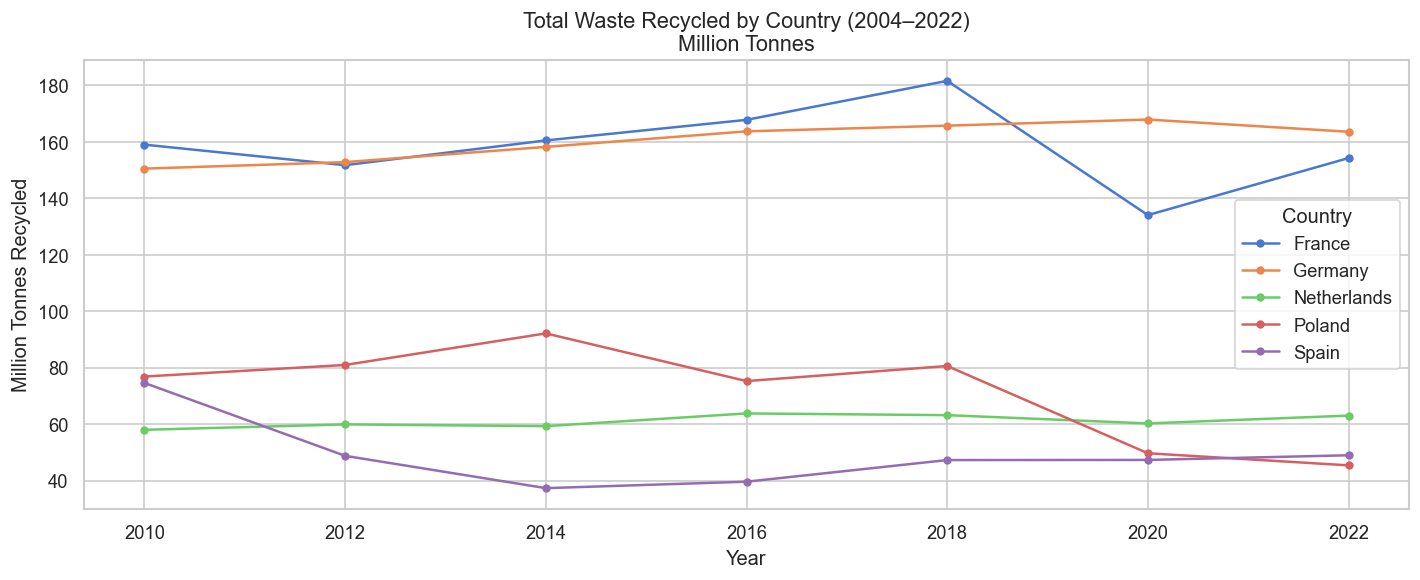

             count   mean   std    min    25%    50%    75%    max
geo                                                               
France         7.0  158.4  14.6  134.0  153.0  159.0  164.1  181.6
Germany        7.0  160.3   6.7  150.5  155.5  163.6  164.7  167.9
Netherlands    7.0   61.0   2.3   58.0   59.6   60.2   63.1   63.8
Poland         7.0   71.5  17.3   45.4   62.4   76.8   80.8   92.1
Spain          7.0   49.1  12.2   37.3   43.4   47.3   48.8   74.6


In [15]:
# H3: Recycling - filter to Tonne unit only
recycling_t = recycling[recycling["unit"] == "Tonne"].copy()
recycling_t["value_mt"] = recycling_t["value"] / 1_000_000  # convert to million tonnes
recycling_t["time"] = pd.to_numeric(recycling_t["time"], errors="coerce")

fig, ax = plt.subplots()
for country, grp in recycling_t.groupby("geo"):
    grp = grp.sort_values("time")
    ax.plot(grp["time"], grp["value_mt"], marker="o", markersize=4, label=country)

ax.set_title("Total Waste Recycled by Country (2004–2022)\nMillion Tonnes", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Million Tonnes Recycled")
ax.legend(title="Country")
plt.tight_layout()
plt.savefig("../data/exports/h3_recycling_rates.png", dpi=150)
plt.show()

print(recycling_t.groupby("geo")["value_mt"].describe().round(1))

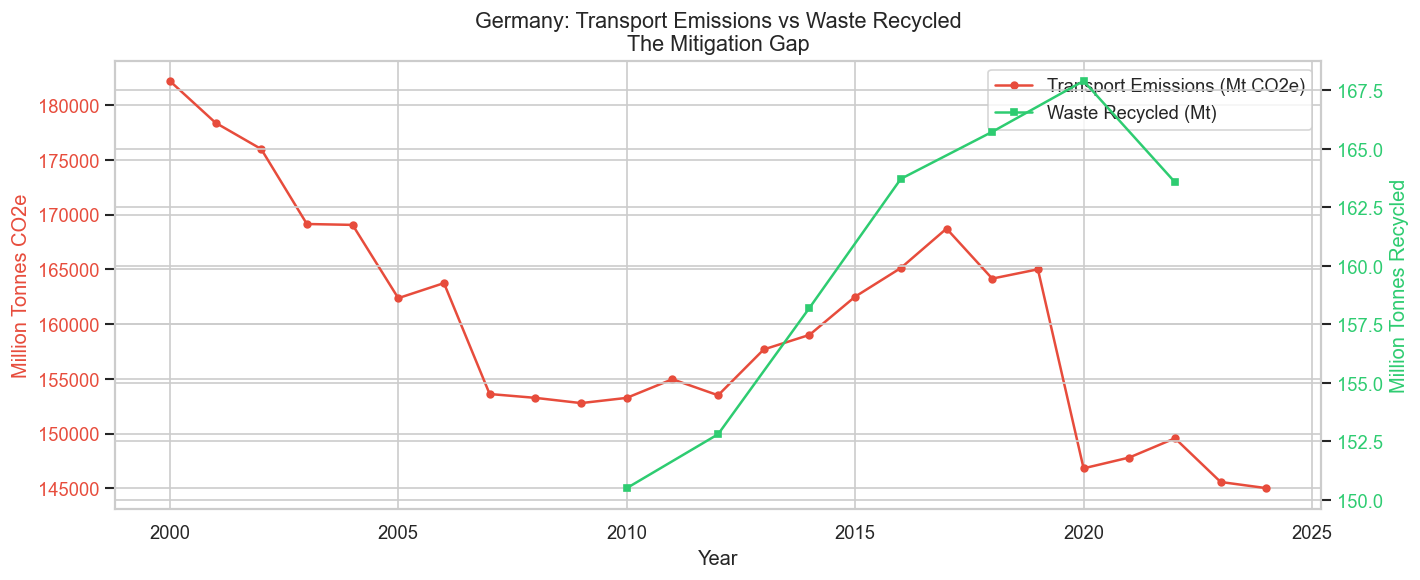

In [16]:
# H3: Mitigation gap — emissions vs recycling for Germany
de_emissions = emissions_agg[emissions_agg["geo"] == "Germany"].sort_values("time")
de_recycling = recycling_t[recycling_t["geo"] == "Germany"].sort_values("time")

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(de_emissions["time"], de_emissions["value"], color="#e74c3c", marker="o", markersize=4, label="Transport Emissions (Mt CO2e)")
ax2.plot(de_recycling["time"], de_recycling["value_mt"], color="#2ecc71", marker="s", markersize=4, label="Waste Recycled (Mt)")

ax1.set_xlabel("Year")
ax1.set_ylabel("Million Tonnes CO2e", color="#e74c3c")
ax2.set_ylabel("Million Tonnes Recycled", color="#2ecc71")
ax1.tick_params(axis="y", labelcolor="#e74c3c")
ax2.tick_params(axis="y", labelcolor="#2ecc71")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title("Germany: Transport Emissions vs Waste Recycled\nThe Mitigation Gap", fontsize=13)
plt.tight_layout()
plt.savefig("../data/exports/h3_mitigation_gap.png", dpi=150)
plt.show()

In [17]:
# Summary stats for the final report
print("=== PROJECT SUMMARY STATISTICS ===\n")

print("H1 — SCALE")
print(f"Germany avg road freight: {freight_total[freight_total['geo']=='Germany']['value'].mean():,.0f} Million TKM")
print(f"Germany max road freight: {freight_total[freight_total['geo']=='Germany']['value'].max():,.0f} Million TKM")
print(f"Germany avg parcels per inhabitant: {postal[postal['country']=='Germany']['parcel_per_inhabitant'].mean():,.0f}")

print("\nH2 — EMISSIONS")
print(f"Germany avg transport emissions: {emissions_agg[emissions_agg['geo']=='Germany']['value'].mean():,.0f} Mt CO2e")
print(f"Germany peak transport emissions: {emissions_agg[emissions_agg['geo']=='Germany']['value'].max():,.0f} Mt CO2e")
print(f"Germany emissions reduction (2000-2023): {((emissions_agg[emissions_agg['geo']=='Germany']['value'].iloc[-1] - emissions_agg[emissions_agg['geo']=='Germany']['value'].iloc[0]) / emissions_agg[emissions_agg['geo']=='Germany']['value'].iloc[0] * 100):.1f}%")

print("\nH3 — MITIGATION")
print(f"Germany avg recycling: {recycling_t[recycling_t['geo']=='Germany']['value_mt'].mean():.1f} Million Tonnes")
print(f"Germany recycling growth (2010-2022): {((recycling_t[recycling_t['geo']=='Germany']['value_mt'].iloc[-1] - recycling_t[recycling_t['geo']=='Germany']['value_mt'].iloc[0]) / recycling_t[recycling_t['geo']=='Germany']['value_mt'].iloc[0] * 100):.1f}%")

=== PROJECT SUMMARY STATISTICS ===

H1 — SCALE
Germany avg road freight: 307,893 Million TKM
Germany max road freight: 343,447 Million TKM
Germany avg parcels per inhabitant: 1,606,644

H2 — EMISSIONS
Germany avg transport emissions: 159,966 Mt CO2e
Germany peak transport emissions: 182,200 Mt CO2e
Germany emissions reduction (2000-2023): -20.4%

H3 — MITIGATION
Germany avg recycling: 160.3 Million Tonnes
Germany recycling growth (2010-2022): 8.7%


In [18]:
# Investigate Germany letter mail drop
de_postal = postal[postal["country"] == "Germany"].sort_values("year")
print(de_postal[["year", "letter_mail_per_inhabitant", "parcel_per_inhabitant"]])

    year  letter_mail_per_inhabitant  parcel_per_inhabitant
13  2012                 7485093.180            1092513.600
14  2013                 7385091.710            1142014.180
15  2014                 7293090.295                    NaN
16  2015                 7294089.830                    NaN
17  2016                 1253015.250            1407017.120
18  2017                 7887493.580            1224014.830
19  2018                 7442780.895            1323314.985
20  2019                 7059401.030            1499898.065
21  2020                 6444402.985            1939074.815
22  2021                 6394253.395            2069533.885
23  2022                 6255122.145            1948385.405
24  2023                 5719809.315            1966000.155
25  2024                 5273892.695            2061321.700


Germany 2016 letter mail value: [1253015.25]
Likely reporting error — value is ~83% below adjacent years


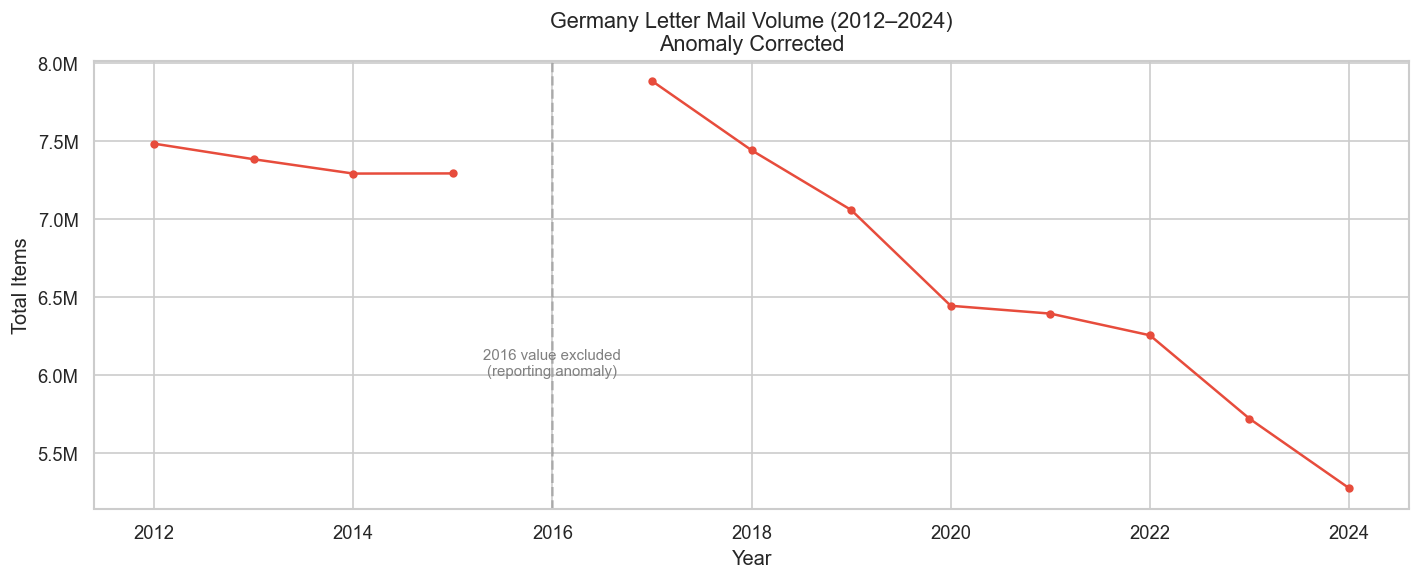


Cleaned Germany letter mail trend:
 year  letter_mail_per_inhabitant
 2012                 7485093.180
 2013                 7385091.710
 2014                 7293090.295
 2015                 7294089.830
 2016                         NaN
 2017                 7887493.580
 2018                 7442780.895
 2019                 7059401.030
 2020                 6444402.985
 2021                 6394253.395
 2022                 6255122.145
 2023                 5719809.315
 2024                 5273892.695


In [19]:
# Data quality note — Germany 2016 letter mail anomaly
print("Germany 2016 letter mail value:", postal.loc[postal["country"]=="Germany"][postal["year"]==2016]["letter_mail_per_inhabitant"].values)
print("Likely reporting error — value is ~83% below adjacent years")

# Flag and exclude the anomaly for trend analysis
postal_clean = postal.copy()
postal_clean.loc[
    (postal_clean["country"] == "Germany") &
    (postal_clean["year"] == 2016) &
    (postal_clean["letter_mail_per_inhabitant"] < 2_000_000),
    "letter_mail_per_inhabitant"
] = None

# Replot Germany letter mail with anomaly removed
de_clean = postal_clean[postal_clean["country"] == "Germany"].sort_values("year")

fig, ax = plt.subplots()
ax.plot(de_clean["year"], de_clean["letter_mail_per_inhabitant"],
        marker="o", markersize=4, color="#e74c3c", label="Letter Mail")
ax.axvline(x=2016, color="gray", linestyle="--", alpha=0.5)
ax.annotate("2016 value excluded\n(reporting anomaly)",
            xy=(2016, 6_000_000), fontsize=9, color="gray", ha="center")
ax.set_title("Germany Letter Mail Volume (2012–2024)\nAnomaly Corrected", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Total Items")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("../data/exports/germany_letter_mail_clean.png", dpi=150)
plt.show()

print("\nCleaned Germany letter mail trend:")
print(de_clean[["year", "letter_mail_per_inhabitant"]].to_string(index=False))

In [20]:
# Flag NaN parcel years for transparency
missing_parcels = postal[postal["parcel_per_inhabitant"].isna()]
print("Missing parcel data points:")
print(missing_parcels[["country", "year"]])

Missing parcel data points:
    country  year
2    France  2014
15  Germany  2014
16  Germany  2015
